# Sigap.ai - Logistic Regression Baseline for Sentiment Analysis

Notebook ini disusun untuk proyek capstone IBM SkillsBuild Sigap.ai sebagai baseline yang dapat langsung dijalankan di Google Colab.

Scope notebook ini dibatasi secara tegas pada data yang sudah final:
- proses data collection sudah selesai
- proses cleaning sudah selesai
- proses labeling sudah selesai
- proses balancing sudah selesai
- proses splitting sudah selesai
- proses preprocessing sudah selesai

Eksperimen ini hanya menggunakan:
- feature: `Review_Text_Processed`
- target: `Sentiment_Label`

Notebook mencakup:
- loading data train/validation/test
- label encoding
- TF-IDF feature engineering
- baseline Logistic Regression
- hyperparameter tuning
- final model training
- evaluasi validation dan test
- visualisasi profesional
- error analysis
- explainable AI
- business analysis
- penyimpanan model dan ekspor hasil

## SECTION 1 - Project Overview

### Tujuan eksperimen
Tujuan eksperimen ini adalah membangun baseline klasifikasi sentimen yang kuat, interpretabel, dan mudah direplikasi untuk dataset review UMKM Indonesia pada proyek Sigap.ai. Fokus utama notebook ini bukan membangun model paling kompleks, tetapi menghasilkan benchmark yang kredibel untuk membandingkan metode lanjutan pada eksperimen berikutnya.

### Alasan menggunakan Logistic Regression sebagai baseline
Logistic Regression merupakan baseline yang tepat untuk problem klasifikasi teks dengan TF-IDF karena:
- bekerja sangat baik pada data sparse berdimensi tinggi
- cepat dilatih dan cepat dievaluasi
- stabil untuk multi-class classification
- mudah diinterpretasikan melalui koefisien fitur
- menjadi pembanding yang solid sebelum mencoba model neural network atau transformer

Dalam konteks capstone, baseline ini juga penting untuk menunjukkan bahwa performa model berasal dari proses yang terukur, bukan dari kompleksitas model semata.

## SECTION 2 - Import Library

Library yang digunakan dibatasi pada stack yang umum dipakai untuk eksperimen machine learning terstruktur:
- Pandas
- Numpy
- Matplotlib
- Seaborn
- Scikit-Learn
- Joblib

In [1]:
import os
from pathlib import Path

import ast
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve, validation_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 11
pd.set_option('display.max_colwidth', 250)
pd.set_option('display.max_columns', 100)

## SECTION 3 - Load Dataset

Notebook ini mencoba menemukan file dataset secara otomatis agar tetap fleksibel saat dijalankan di Google Colab maupun pada workspace lokal.

Jika nama file Anda adalah `df_train_final.csv`, `df_validation_final.csv`, dan `df_test_final.csv`, notebook akan tetap mencarinya. Jika file yang tersedia adalah `train_final.csv`, `validation_final.csv`, dan `test_final.csv`, notebook juga akan menggunakannya.

In [2]:
PROJECT_ROOT = Path.cwd()

TRAIN_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "train.csv"
VAL_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "validation.csv"
TEST_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "test.csv"

print(TRAIN_PATH)
print(VAL_PATH)
print(TEST_PATH)

df_train = pd.read_csv(TRAIN_PATH)
df_val = pd.read_csv(VAL_PATH)
df_test = pd.read_csv(TEST_PATH)

print("\nDataset Loaded Successfully")
print("Train      :", df_train.shape)
print("Validation :", df_val.shape)
print("Test       :", df_test.shape)

print("\nColumns:")
print(df_train.columns.tolist())

c:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\dataset\processed-dataset\train.csv
c:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\dataset\processed-dataset\validation.csv
c:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\dataset\processed-dataset\test.csv

Dataset Loaded Successfully
Train      : (23323, 9)
Validation : (5015, 9)
Test       : (5009, 9)

Columns:
['Review_Text', 'Review_Text_Processed', 'Review_Date', 'Rating_Score', 'Business_Category', 'Sentiment_Label', 'Review_Aspect', 'Crisis_Flag', 'Is_Sarcasm']


In [3]:
expected_columns = [
    'Review_Text',
    'Review_Text_Processed',
    'Review_Date',
    'Rating_Score',
    'Business_Category',
    'Sentiment_Label',
    'Review_Aspect',
    'Crisis_Flag',
    'Is_Sarcasm'
]

for split_name, df in [
    ('Train', df_train),
    ('Validation', df_val),
    ('Test', df_test)
]:
    missing = [c for c in expected_columns if c not in df.columns]

    if missing:
        raise ValueError(
            f'{split_name} missing columns: {missing}'
        )

    print(f'\n{split_name} shape: {df.shape}')
    print('Label distribution:')
    display(df['Sentiment_Label'].value_counts().to_frame('count'))

    print('Sample data:')
    display(
        df[
            ['Review_Text_Processed', 'Sentiment_Label']
        ].head(5)
    )

train_df = df_train.copy()
val_df = df_val.copy()
test_df = df_test.copy()

print("\nDataset validation passed")


Train shape: (23323, 9)
Label distribution:


,count
Sentiment_Label,
Netral,7787
Negative,7779
Positive,7757


Sample data:


,Review_Text_Processed,Sentiment_Label
0,bikin tagih,Positive
1,banget suka terima kasih bs,Positive
2,rib eye 115rb belum ppn segi harga mahal sesuai qualitas product taste aroma visual qualitas steak ambil saos bbq saos bbq flavournya,Positive
3,gabisa reedem app belum baharu udah palinh appnya jelas,Netral
4,tahun semenjak pakai grab titik lokasi tidak ubah rmh tidak pindah lokasi hr driver pesan komplain tidak sesuai titik beda bbrp meter tidak sesuai patok logika dmn gw mesan tengah malam driver tidak komplain kranaudh tahun pakai chat gw blng rmh ...,Positive



Validation shape: (5015, 9)
Label distribution:


...


Test shape: (5009, 9)
Label distribution:


,count
Sentiment_Label,
Netral,1672
Negative,1671
Positive,1666


Sample data:


,Review_Text_Processed,Sentiment_Label
0,original official store kirim lumayan official store cepat toko,Negative
1,lupluppp banyakk resto jangan berubahh,Positive
2,cancel beli penasaran nyobain 1kg packingan hancur ngunyah tidak ken brenti ueenaaakk saran seller next packingan tidak hancur udara balut bubble alam dpt kripik pisang kasih sukses yah,Positive
3,info kopi fore cendana loske,Positive
4,teri lbh asin,Netral



Dataset validation passed


## SECTION 4 - Label Encoding

Target label pada dataset menggunakan istilah `Netral`, sedangkan eksperimen ini menggunakan standar akademik yang lebih konsisten, yaitu `Neutral`.

Pada tahap ini:
- label distandarkan menjadi `Positive`, `Neutral`, `Negative`
- label kemudian diencode menggunakan `LabelEncoder`
- mapping label disimpan agar interpretasi hasil tetap transparan

In [4]:
def standardize_label(label):
    label = str(label).strip()
    if label.lower() == 'netral':
        return 'Neutral'
    return label

for df in [train_df, val_df, test_df]:
    df['Sentiment_Label'] = df['Sentiment_Label'].apply(standardize_label)

label_order = ['Negative', 'Neutral', 'Positive']
label_encoder = LabelEncoder()
label_encoder.fit(label_order)

label_mapping = {label: int(label_encoder.transform([label])[0]) for label in label_encoder.classes_}
inverse_label_mapping = {v: k for k, v in label_mapping.items()}

print('Label Mapping:')
display(pd.DataFrame({'label': list(label_mapping.keys()), 'encoded_value': list(label_mapping.values())}))

train_y = label_encoder.transform(train_df['Sentiment_Label'])
val_y = label_encoder.transform(val_df['Sentiment_Label'])
test_y = label_encoder.transform(test_df['Sentiment_Label'])

print('Encoded classes:', list(label_encoder.classes_))

Label Mapping:


,label,encoded_value
0,Negative,0
1,Neutral,1
2,Positive,2


Encoded classes: [np.str_('Negative'), np.str_('Neutral'), np.str_('Positive')]


## SECTION 5 - TF-IDF Feature Engineering

Eksperimen TF-IDF dilakukan untuk membandingkan representasi teks yang berbeda sebelum model final dibangun.

Konfigurasi yang diuji:
1. Unigram
2. Unigram + Bigram
3. Tuning `max_features`

Semua eksperimen pada section ini memakai Logistic Regression default sebagai pembanding, lalu dievaluasi pada validation set.

,experiment,ngram_range,max_features,accuracy,precision_macro,recall_macro,f1_macro,vocab_size
0,max_features=20000,"(1, 2)",20000,0.775075,0.774661,0.775092,0.774682,20000
1,max_features=10000,"(1, 2)",10000,0.770887,0.770402,0.770905,0.770533,10000
2,Unigram + Bigram,"(1, 2)",10000,0.770887,0.770402,0.770905,0.770533,10000
3,max_features=5000,"(1, 2)",5000,0.767697,0.767185,0.767718,0.767320,5000
4,Unigram,"(1, 1)",10000,0.766700,0.766262,0.766716,0.766415,10000


C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_15632\3054660917.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


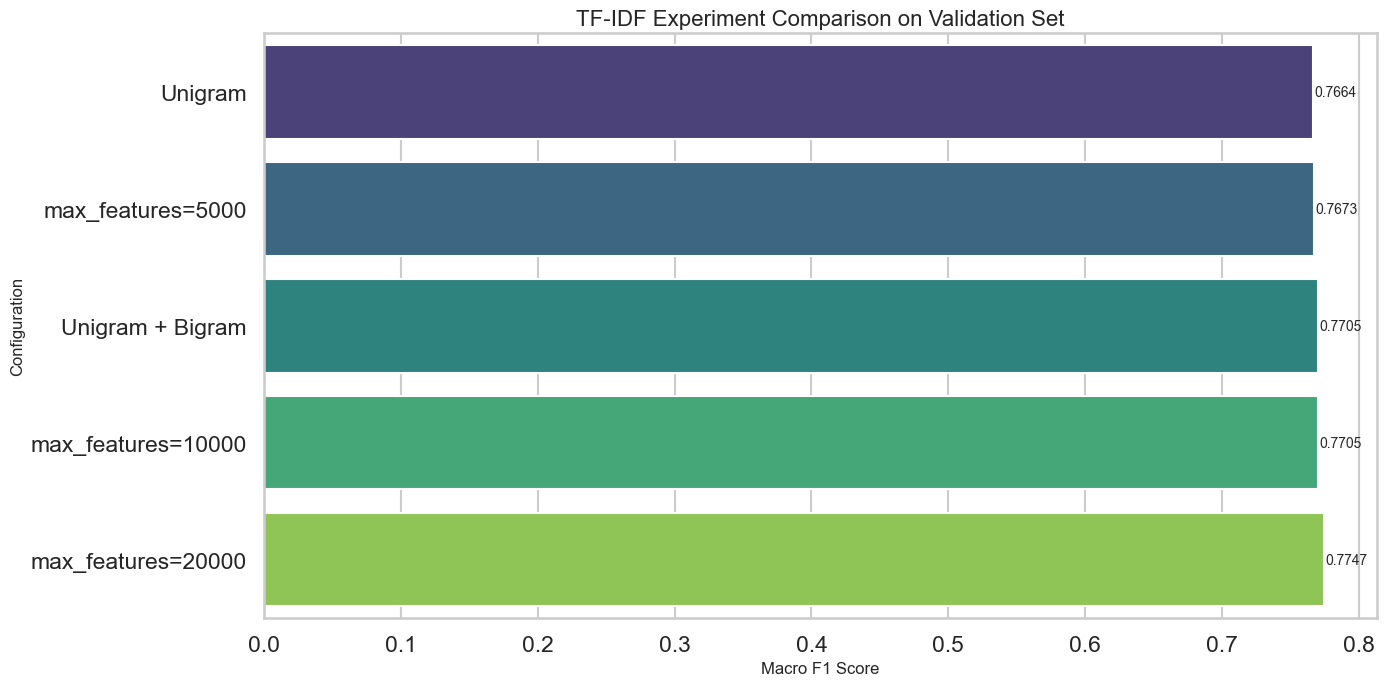


Best TF-IDF Configuration
{'ngram_range': (1, 2), 'max_features': 20000, 'min_df': 2, 'max_df': 0.95}

Best Validation F1
0.7747


In [5]:
X_train = train_df['Review_Text_Processed'].fillna('').astype(str)
X_val = val_df['Review_Text_Processed'].fillna('').astype(str)
X_test = test_df['Review_Text_Processed'].fillna('').astype(str)


def build_pipeline(tfidf_params, lr_params=None):
    if lr_params is None:
        lr_params = {}

    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        sublinear_tf=True,
        norm='l2',
        **tfidf_params
    )

    classifier = LogisticRegression(
        random_state=42,
        max_iter=1000,
        **lr_params
    )

    return Pipeline([
        ('tfidf', vectorizer),
        ('logreg', classifier)
    ])


def evaluate_pipeline(
    pipeline,
    x_train,
    y_train,
    x_eval,
    y_eval
):
    pipeline.fit(x_train, y_train)

    pred = pipeline.predict(x_eval)
    proba = pipeline.predict_proba(x_eval)

    return {
        'accuracy': accuracy_score(y_eval, pred),
        'precision_macro': precision_score(
            y_eval,
            pred,
            average='macro',
            zero_division=0
        ),
        'recall_macro': recall_score(
            y_eval,
            pred,
            average='macro',
            zero_division=0
        ),
        'f1_macro': f1_score(
            y_eval,
            pred,
            average='macro',
            zero_division=0
        ),
        'pred': pred,
        'proba': proba,
        'pipeline': pipeline
    }


experiment_rows = []

# EXPERIMENT 1
# UNIGRAM VS BIGRAM

base_max_features = 10000

ngram_experiments = [
    (
        'Unigram',
        {
            'ngram_range': (1, 1),
            'max_features': base_max_features,
            'min_df': 2,
            'max_df': 0.95
        }
    ),
    (
        'Unigram + Bigram',
        {
            'ngram_range': (1, 2),
            'max_features': base_max_features,
            'min_df': 2,
            'max_df': 0.95
        }
    )
]

for exp_name, tfidf_params in ngram_experiments:

    pipeline = build_pipeline(tfidf_params)

    result = evaluate_pipeline(
        pipeline,
        X_train,
        train_y,
        X_val,
        val_y
    )

    experiment_rows.append({
        'experiment': exp_name,
        'ngram_range': str(tfidf_params['ngram_range']),
        'max_features': tfidf_params['max_features'],
        'accuracy': result['accuracy'],
        'precision_macro': result['precision_macro'],
        'recall_macro': result['recall_macro'],
        'f1_macro': result['f1_macro'],
        'vocab_size': len(
            result['pipeline']
            .named_steps['tfidf']
            .vocabulary_
        )
    })

experiment_results = pd.DataFrame(experiment_rows)

best_ngram_row = (
    experiment_results
    .sort_values(
        'f1_macro',
        ascending=False
    )
    .iloc[0]
)

best_ngram_range = ast.literal_eval(
    best_ngram_row['ngram_range']
)

# EXPERIMENT 2
# MAX FEATURES

max_features_grid = [
    5000,
    10000,
    20000
]

for mf in max_features_grid:

    tfidf_params = {
        'ngram_range': best_ngram_range,
        'max_features': mf,
        'min_df': 2,
        'max_df': 0.95
    }

    pipeline = build_pipeline(tfidf_params)

    result = evaluate_pipeline(
        pipeline,
        X_train,
        train_y,
        X_val,
        val_y
    )

    experiment_rows.append({
        'experiment': f'max_features={mf}',
        'ngram_range': str(tfidf_params['ngram_range']),
        'max_features': tfidf_params['max_features'],
        'accuracy': result['accuracy'],
        'precision_macro': result['precision_macro'],
        'recall_macro': result['recall_macro'],
        'f1_macro': result['f1_macro'],
        'vocab_size': len(
            result['pipeline']
            .named_steps['tfidf']
            .vocabulary_
        )
    })

# RESULT TABLE

experiment_results = (
    pd.DataFrame(experiment_rows)
    .sort_values(
        'f1_macro',
        ascending=False
    )
    .reset_index(drop=True)
)

display(experiment_results)

# VISUALIZATION

fig, ax = plt.subplots(
    figsize=(14, 7)
)

plot_df = experiment_results.sort_values(
    'f1_macro',
    ascending=True
)

sns.barplot(
    data=plot_df,
    x='f1_macro',
    y='experiment',
    palette='viridis',
    ax=ax
)

ax.set_title(
    'TF-IDF Experiment Comparison on Validation Set'
)

ax.set_xlabel(
    'Macro F1 Score'
)

ax.set_ylabel(
    'Configuration'
)

for i, v in enumerate(plot_df['f1_macro']):
    ax.text(
        v + 0.001,
        i,
        f'{v:.4f}',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

# BEST CONFIGURATION

best_feature_row = experiment_results.iloc[0]

BEST_TFIDF_PARAMS = {
    'ngram_range': ast.literal_eval(
        best_feature_row['ngram_range']
    ),
    'max_features': int(
        best_feature_row['max_features']
    ),
    'min_df': 2,
    'max_df': 0.95
}

print("\nBest TF-IDF Configuration")
print(BEST_TFIDF_PARAMS)

print("\nBest Validation F1")
print(
    round(
        best_feature_row['f1_macro'],
        4
    )
)

## SECTION 6 - Baseline Model

Baseline Logistic Regression dilatih menggunakan konfigurasi TF-IDF terbaik dari Section 5, dengan hyperparameter Logistic Regression tetap default.

Tujuannya adalah mendapatkan baseline yang stabil dan langsung bisa dibandingkan dengan hasil tuning berikutnya.

In [6]:
baseline_model = build_pipeline(BEST_TFIDF_PARAMS)
baseline_model.fit(X_train, train_y)

val_pred_baseline = baseline_model.predict(X_val)

baseline_validation_metrics = {
    'split': 'validation',
    'accuracy': accuracy_score(val_y, val_pred_baseline),
    'precision_macro': precision_score(val_y, val_pred_baseline, average='macro', zero_division=0),
    'recall_macro': recall_score(val_y, val_pred_baseline, average='macro', zero_division=0),
    'f1_macro': f1_score(val_y, val_pred_baseline, average='macro', zero_division=0),
}

baseline_validation_metrics_df = pd.DataFrame([baseline_validation_metrics])
display(baseline_validation_metrics_df)

print('Classification Report - Baseline Validation')
print(classification_report(val_y, val_pred_baseline, target_names=label_encoder.classes_, digits=4, zero_division=0))

,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.775075,0.774661,0.775092,0.774682


Classification Report - Baseline Validation
              precision    recall  f1-score   support

    Negative     0.7703    0.7634    0.7669      1674
     Neutral     0.7610    0.7355    0.7480      1671
    Positive     0.7926    0.8263    0.8091      1670

    accuracy                         0.7751      5015
   macro avg     0.7747    0.7751    0.7747      5015
weighted avg     0.7747    0.7751    0.7747      5015



## SECTION 7 - Hyperparameter Tuning

Hyperparameter tuning dilakukan menggunakan GridSearchCV pada training set saja agar validation set tetap berfungsi sebagai evaluasi yang lebih independen.

Grid yang diuji:
- `C = [0.01, 0.1, 1, 10, 100]`
- `solver = ['lbfgs', 'liblinear']`
- `class_weight = [None, 'balanced']`
- `max_iter = [1000, 2000]`

Scoring yang digunakan adalah `f1_macro` karena dataset sentimen multi-class dan membutuhkan evaluasi yang seimbang antar kelas.

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best Parameters:
{'logreg__C': 1, 'logreg__class_weight': None, 'logreg__max_iter': 1000, 'logreg__solver': 'lbfgs'}
Best CV F1 Macro: 0.7668761177132043


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,param_logreg__C,param_logreg__solver,param_logreg__class_weight,param_logreg__max_iter
0,1,0.766876,0.002968,0.880854,0.000865,1.00,lbfgs,NaN,2000
1,1,0.766876,0.002968,0.880854,0.000865,1.00,lbfgs,NaN,1000
2,3,0.766560,0.003572,0.879704,0.000633,1.00,lbfgs,balanced,1000
3,3,0.766560,0.003572,0.879704,0.000633,1.00,lbfgs,balanced,2000
4,5,0.762424,0.003777,0.856185,0.001269,1.00,liblinear,NaN,1000
5,5,0.762424,0.003777,0.856185,0.001269,1.00,liblinear,NaN,2000
6,7,0.762409,0.003876,0.856067,0.001356,1.00,liblinear,balanced,2000
7,7,0.762409,0.003876,0.856067,0.001356,1.00,liblinear,balanced,1000
8,9,0.753896,0.002254,0.952982,0.001300,10.00,liblinear,balanced,1000
9,9,0.753896,0.002254,0.952982,0.001300,10.00,liblinear,balanced,2000


C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_15632\590366012.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_grid.sort_values('mean_test_score', ascending=True), x='mean_test_score', y='config', palette='mako', ax=ax)


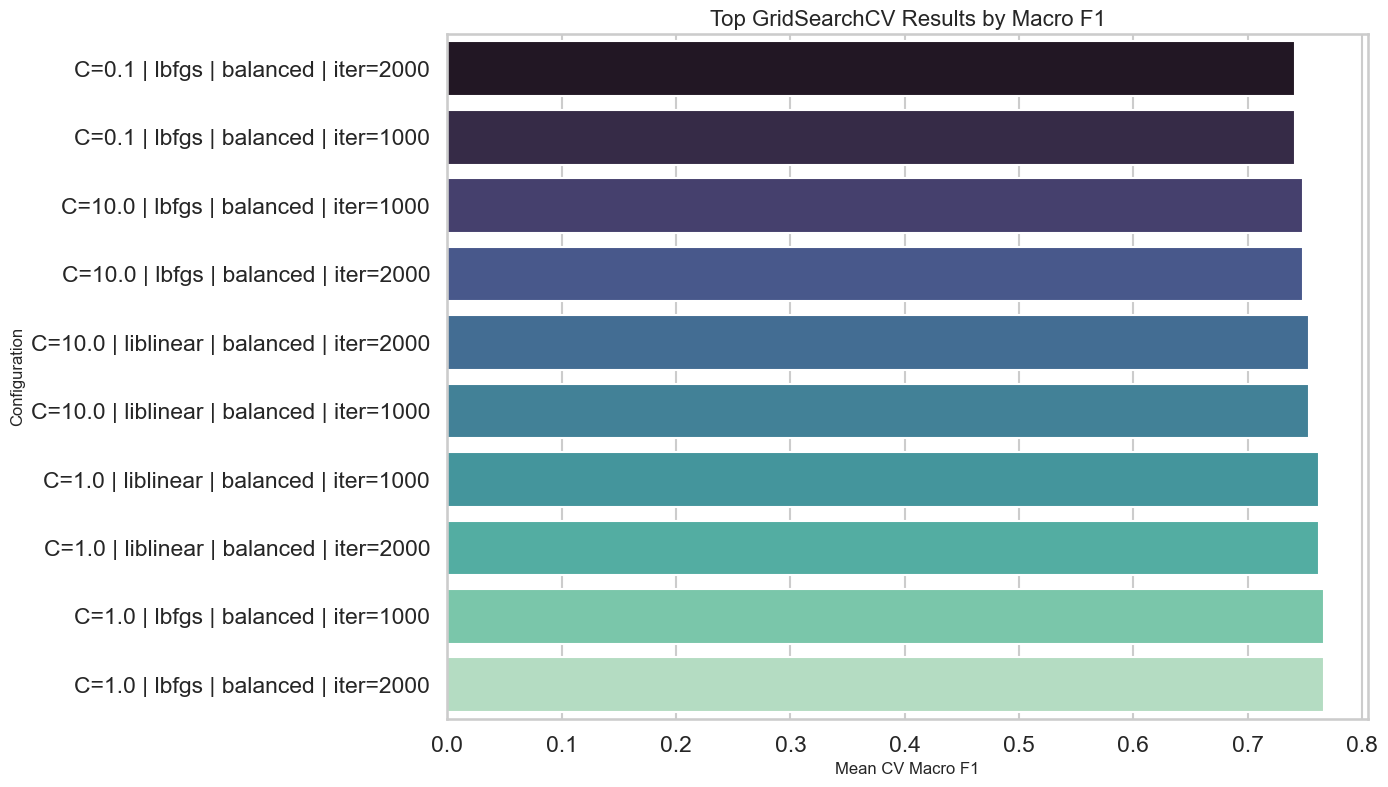

In [7]:
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

tuning_model = build_pipeline(BEST_TFIDF_PARAMS)
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__solver': ['lbfgs', 'liblinear'],
    'logreg__class_weight': [None, 'balanced'],
    'logreg__max_iter': [1000, 2000],
}

grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
)

grid_search.fit(X_train, train_y)

print('Best Parameters:')
print(grid_search.best_params_)
print('Best CV F1 Macro:', grid_search.best_score_)

grid_results = pd.DataFrame(grid_search.cv_results_)
cols_to_show = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'std_train_score',
    'param_logreg__C',
    'param_logreg__solver',
    'param_logreg__class_weight',
    'param_logreg__max_iter',
]
grid_results_table = grid_results[cols_to_show].sort_values('rank_test_score').reset_index(drop=True)
display(grid_results_table)

fig, ax = plt.subplots(figsize=(14, 8))
sorted_grid = grid_results_table.head(20).copy()
sorted_grid['config'] = (
    'C=' + sorted_grid['param_logreg__C'].astype(str) +
    ' | ' + sorted_grid['param_logreg__solver'].astype(str) +
    ' | ' + sorted_grid['param_logreg__class_weight'].astype(str) +
    ' | iter=' + sorted_grid['param_logreg__max_iter'].astype(str)
)
sns.barplot(data=sorted_grid.sort_values('mean_test_score', ascending=True), x='mean_test_score', y='config', palette='mako', ax=ax)
ax.set_title('Top GridSearchCV Results by Macro F1')
ax.set_xlabel('Mean CV Macro F1')
ax.set_ylabel('Configuration')
plt.tight_layout()
plt.show()

## SECTION 8 - Final Model Training

Final model dibangun menggunakan parameter terbaik dari GridSearchCV. Model kemudian dilatih kembali pada training set agar seluruh data latih berkontribusi pada parameter final.

In [8]:
final_model = build_pipeline(BEST_TFIDF_PARAMS)
final_model.set_params(**grid_search.best_params_)
final_model.fit(X_train, train_y)

final_vectorizer = final_model.named_steps['tfidf']
final_classifier = final_model.named_steps['logreg']

print('Final model fitted successfully.')
print('Vocabulary size:', len(final_vectorizer.vocabulary_))

Final model fitted successfully.
Vocabulary size: 20000


## SECTION 9 - Evaluation

Evaluasi dilakukan pada validation set dan test set dengan metrik berikut:
- Accuracy
- Precision
- Recall
- F1 Score

Selain metrik agregat, notebook juga menampilkan classification report lengkap untuk masing-masing split.

In [9]:
def evaluate_model(model, x, y, split_name):
    pred = model.predict(x)
    proba = model.predict_proba(x)
    metrics = {
        'split': split_name,
        'accuracy': accuracy_score(y, pred),
        'precision_macro': precision_score(y, pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y, pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y, pred, average='macro', zero_division=0),
    }
    report_dict = classification_report(
        y,
        pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={'index': 'label'})
    return metrics, pred, proba, report_df

val_metrics, val_pred, val_proba, val_report_df = evaluate_model(final_model, X_val, val_y, 'validation')
test_metrics, test_pred, test_proba, test_report_df = evaluate_model(final_model, X_test, test_y, 'test')

metrics_df = pd.DataFrame([val_metrics, test_metrics])
display(metrics_df)
display(val_report_df)
display(test_report_df)

print('Validation Classification Report')
print(classification_report(val_y, val_pred, target_names=label_encoder.classes_, digits=4, zero_division=0))

print('Test Classification Report')
print(classification_report(test_y, test_pred, target_names=label_encoder.classes_, digits=4, zero_division=0))

,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.775075,0.774661,0.775092,0.774682
1,test,0.771012,0.770407,0.771088,0.770374


,label,precision,recall,f1-score,support
0,Negative,0.770344,0.763441,0.766877,1674.000000
1,Neutral,0.760991,0.735488,0.748022,1671.000000
2,Positive,0.792648,0.826347,0.809147,1670.000000
3,accuracy,0.775075,0.775075,0.775075,0.775075
4,macro avg,0.774661,0.775092,0.774682,5015.000000
5,weighted avg,0.774655,0.775075,0.774670,5015.000000


,label,precision,recall,f1-score,support
0,Negative,0.754540,0.770796,0.762581,1671.000000
1,Neutral,0.754140,0.708134,0.730413,1672.000000
2,Positive,0.802540,0.834334,0.818128,1666.000000
3,accuracy,0.771012,0.771012,0.771012,0.771012
4,macro avg,0.770407,0.771088,0.770374,5009.000000
5,weighted avg,0.770372,0.771012,0.770319,5009.000000


Validation Classification Report
              precision    recall  f1-score   support

    Negative     0.7703    0.7634    0.7669      1674
     Neutral     0.7610    0.7355    0.7480      1671
    Positive     0.7926    0.8263    0.8091      1670

    accuracy                         0.7751      5015
   macro avg     0.7747    0.7751    0.7747      5015
weighted avg     0.7747    0.7751    0.7747      5015

Test Classification Report
              precision    recall  f1-score   support

    Negative     0.7545    0.7708    0.7626      1671
     Neutral     0.7541    0.7081    0.7304      1672
    Positive     0.8025    0.8343    0.8181      1666

    accuracy                         0.7710      5009
   macro avg     0.7704    0.7711    0.7704      5009
weighted avg     0.7704    0.7710    0.7703      5009



## SECTION 10 - Visualization

Visualisasi dibuat untuk membantu interpretasi performa model secara akademik dan presentatif.

Visualisasi yang disediakan:
1. Confusion Matrix Heatmap
2. ROC Curve multiclass
3. Precision Recall Curve
4. Learning Curve
5. Validation Curve
6. Class Distribution Prediction

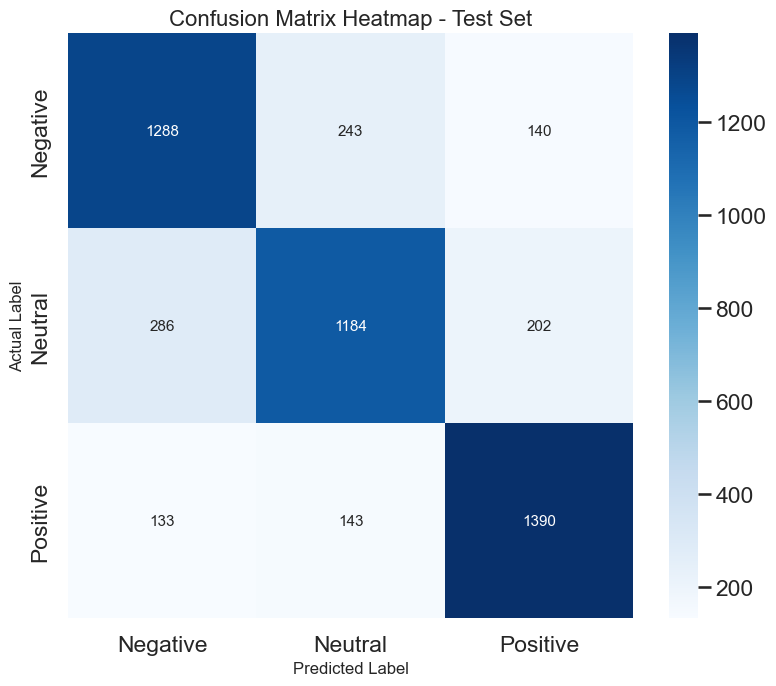

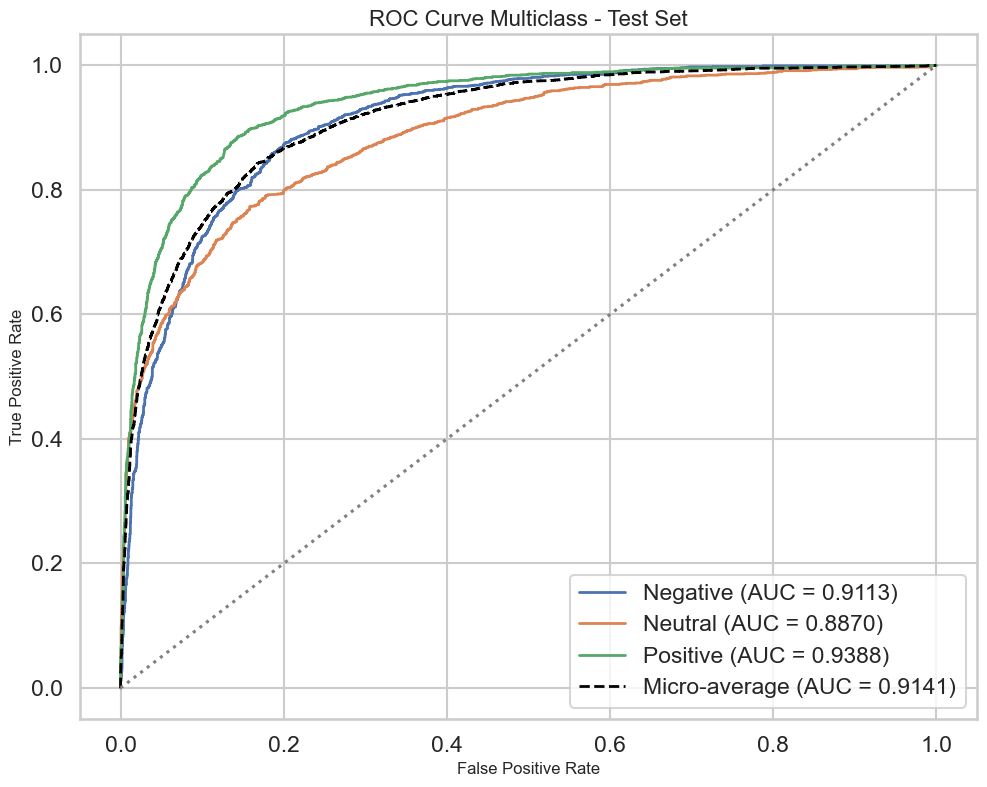

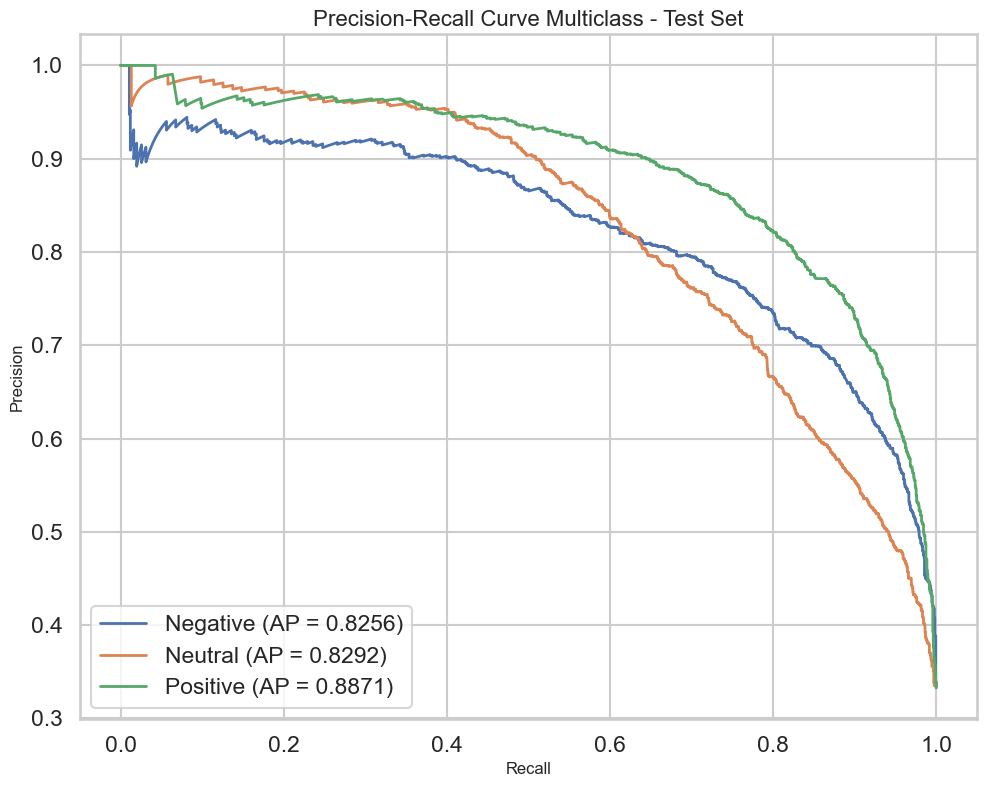

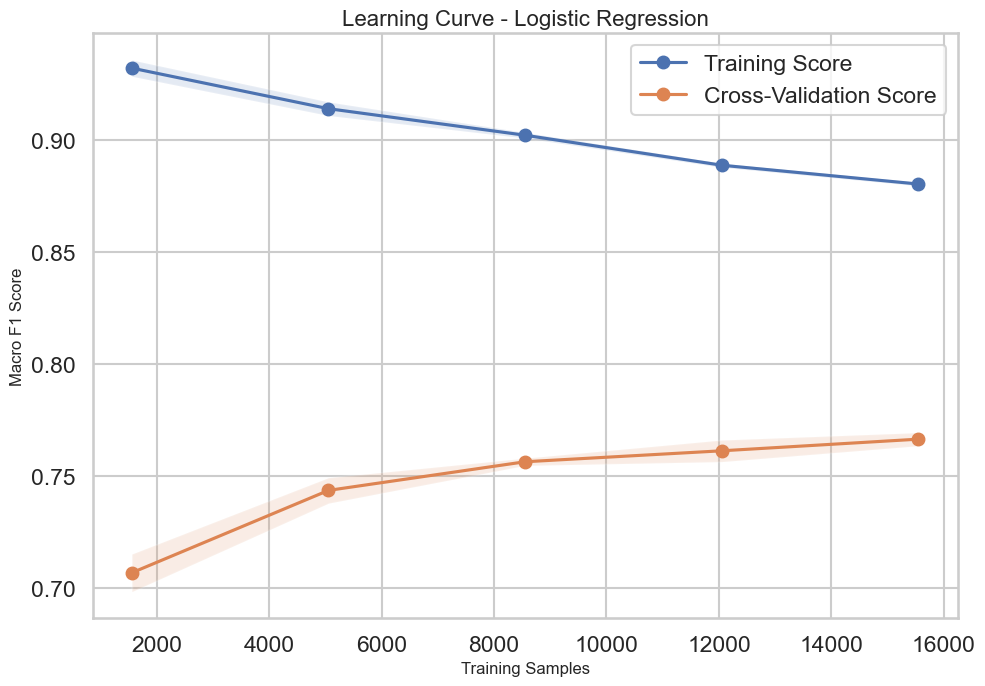

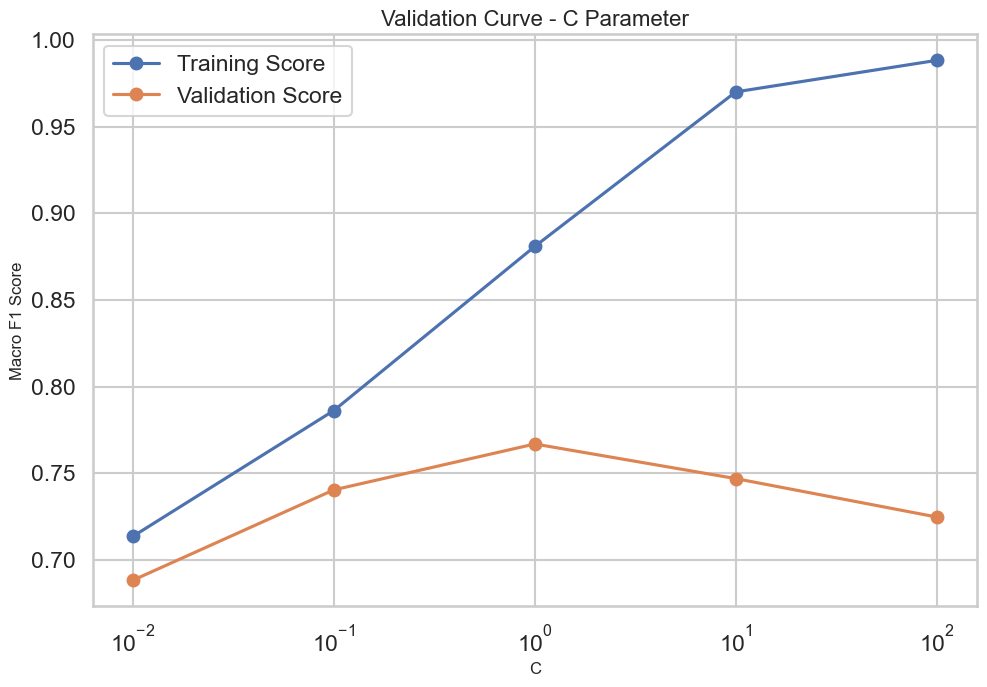

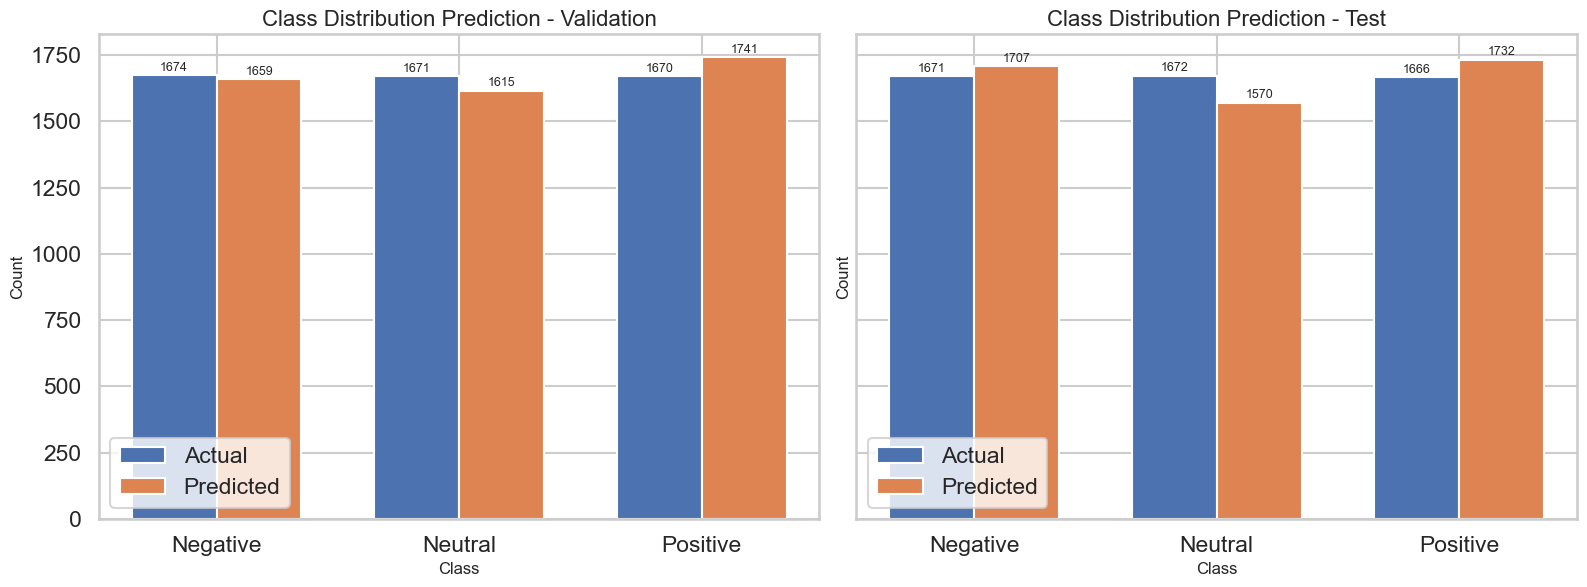

In [10]:
class_names = list(label_encoder.classes_)

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(test_y, test_pred)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix Heatmap - Test Set')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
plt.tight_layout()
plt.show()

# 2. ROC Curve Multiclass
fig, ax = plt.subplots(figsize=(10, 8))
y_test_bin = label_binarize(test_y, classes=list(range(len(class_names))))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{cls} (AUC = {roc_auc:.4f})')

fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), test_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
ax.plot(fpr_micro, tpr_micro, linestyle='--', color='black', linewidth=2, label=f'Micro-average (AUC = {roc_auc_micro:.4f})')
ax.plot([0, 1], [0, 1], linestyle=':', color='grey')
ax.set_title('ROC Curve Multiclass - Test Set')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 3. Precision-Recall Curve
fig, ax = plt.subplots(figsize=(10, 8))
for i, cls in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], test_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], test_proba[:, i])
    ax.plot(recall, precision, linewidth=2, label=f'{cls} (AP = {ap:.4f})')
ax.set_title('Precision-Recall Curve Multiclass - Test Set')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

# 4. Learning Curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=final_model,
    X=X_train,
    y=train_y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42,
)
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(train_sizes, train_mean, marker='o', label='Training Score')
ax.plot(train_sizes, valid_mean, marker='o', label='Cross-Validation Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
ax.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.15)
ax.set_title('Learning Curve - Logistic Regression')
ax.set_xlabel('Training Samples')
ax.set_ylabel('Macro F1 Score')
ax.legend()
plt.tight_layout()
plt.show()

# 5. Validation Curve
c_values = np.array([0.01, 0.1, 1, 10, 100])
val_train_scores, val_test_scores = validation_curve(
    estimator=final_model,
    X=X_train,
    y=train_y,
    param_name='logreg__C',
    param_range=c_values,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(c_values, val_train_scores.mean(axis=1), marker='o', label='Training Score')
ax.plot(c_values, val_test_scores.mean(axis=1), marker='o', label='Validation Score')
ax.set_xscale('log')
ax.set_title('Validation Curve - C Parameter')
ax.set_xlabel('C')
ax.set_ylabel('Macro F1 Score')
ax.legend()
plt.tight_layout()
plt.show()

# 6. Class Distribution Prediction
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
actual_pred_tables = {
    'Validation': pd.DataFrame({'Actual': pd.Series(val_y).map(inverse_label_mapping).value_counts(), 'Predicted': pd.Series(val_pred).map(inverse_label_mapping).value_counts()}),
    'Test': pd.DataFrame({'Actual': pd.Series(test_y).map(inverse_label_mapping).value_counts(), 'Predicted': pd.Series(test_pred).map(inverse_label_mapping).value_counts()}),
}

for ax, (split_name, table) in zip(axes, actual_pred_tables.items()):
    plot_table = table.reindex(class_names).fillna(0)
    x = np.arange(len(class_names))
    width = 0.35
    ax.bar(x - width / 2, plot_table['Actual'].values, width=width, label='Actual')
    ax.bar(x + width / 2, plot_table['Predicted'].values, width=width, label='Predicted')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.set_title(f'Class Distribution Prediction - {split_name}')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.legend()
    for i, value in enumerate(plot_table['Actual'].values):
        ax.text(i - width / 2, value + 5, str(int(value)), ha='center', va='bottom', fontsize=9)
    for i, value in enumerate(plot_table['Predicted'].values):
        ax.text(i + width / 2, value + 5, str(int(value)), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## SECTION 11 - Error Analysis

Error analysis difokuskan pada contoh yang salah klasifikasi di test set karena test set adalah representasi paling ketat dari generalisasi model.

Tabel berikut menampilkan 50 contoh salah klasifikasi dengan kolom:
- `Review_Text`
- `Actual_Label`
- `Predicted_Label`

In [11]:
test_predictions_df = pd.DataFrame({
    'Review_Text': test_df['Review_Text'],
    'Review_Text_Processed': test_df['Review_Text_Processed'],
    'Actual_Label': pd.Series(test_y).map(inverse_label_mapping),
    'Predicted_Label': pd.Series(test_pred).map(inverse_label_mapping),
    'Crisis_Flag': test_df['Crisis_Flag'].values,
    'Is_Sarcasm': test_df['Is_Sarcasm'].values,
    'Business_Category': test_df['Business_Category'].values,
})

misclassified_df = test_predictions_df[test_predictions_df['Actual_Label'] != test_predictions_df['Predicted_Label']].copy()
error_examples = misclassified_df[['Review_Text', 'Actual_Label', 'Predicted_Label']].head(50)

display(error_examples)

print('Jumlah salah klasifikasi:', len(misclassified_df))
print('Error rate:', round(len(misclassified_df) / len(test_predictions_df) * 100, 2), '%')

print('\nPola kesalahan utama:')
print('- Review pendek atau sangat ringkas lebih sulit dibedakan antar kelas.')
print('- Ulasan netral sering tertukar dengan positif atau negatif jika mengandung kata evaluatif yang ambigu.')
print('- Kasus sarcasm cenderung meningkatkan risiko salah klasifikasi.')
print('- Review dengan konteks domain tertentu, terutama yang sangat spesifik, dapat diprediksi kurang stabil jika kosakata latih terbatas.')

confusion_pairs = misclassified_df.groupby(['Actual_Label', 'Predicted_Label']).size().sort_values(ascending=False).to_frame('count')
display(confusion_pairs.head(10))

length_summary = misclassified_df['Review_Text_Processed'].fillna('').astype(str).str.split().str.len().describe().to_frame('misclassified_length')
display(length_summary)

,Review_Text,Actual_Label,Predicted_Label
1,"lupluppp banyakk buat resto, untuk rasa jangan sampai berubahh",Positive,Neutral
3,info kopi yg enak selain fore cendana loske .,Positive,Neutral
4,ternyata terinya kecil..dan lbh asin dari yg biasa..,Neutral,Negative
7,"Nemu RM ini dari Google, terpilih Karena ga jauh dr pintu Tol Serang, melipir sejenak sebelum melanjutkan perjalanan ke Cilegon.. parkir luas, Rasa makanan Biasa, Minuman jus mangga ga seger sama sekali, Porsi makanan Banyak, harga lumayan mahal,...",Neutral,Negative
8,ambiance was good here. veg sizzlers we ordered are not upto the mark. it can be improved more. pelayanan was also very lambat. over all it's ok for one time visit.,Positive,Neutral
10,Nasi matang merata 👍. Gampang dibersihkan. Nasinya tahan lama 🍚.,Negative,Positive
14,Tidak bisa order ....,Neutral,Negative
16,"paling sebel sama driver yg batalin pesenan grabfood. hnya karena rumahku masuk2 gang. namanya jg tengah kota padat penduduk. suamiku driver grab juga, gak masalah sama antar pesanan ke gang2. Krn bukan cuma sekali dua sih, bikin sebel 😩😭",Neutral,Negative
19,"Bahannya tipis dan ukuran XL nya kekecilan, terlalu sempit utk dipakai",Neutral,Negative
20,"there is no gulab jamun, so reducing one star",Positive,Negative


Jumlah salah klasifikasi: 1147
Error rate: 22.9 %

Pola kesalahan utama:
- Review pendek atau sangat ringkas lebih sulit dibedakan antar kelas.
- Ulasan netral sering tertukar dengan positif atau negatif jika mengandung kata evaluatif yang ambigu.
- Kasus sarcasm cenderung meningkatkan risiko salah klasifikasi.
- Review dengan konteks domain tertentu, terutama yang sangat spesifik, dapat diprediksi kurang stabil jika kosakata latih terbatas.


,,count
Actual_Label,Predicted_Label,
Neutral,Negative,286
Negative,Neutral,243
Neutral,Positive,202
Positive,Neutral,143
Negative,Positive,140
Positive,Negative,133


,misclassified_length
count,1147.000000
mean,19.093287
std,28.174305
min,1.000000
25%,5.000000
50%,10.000000
75%,22.000000
max,395.000000


## SECTION 12 - Explainable AI

Koefisien Logistic Regression digunakan untuk mengekstrak kata-kata yang paling berkontribusi pada masing-masing kelas.

Interpretasi yang digunakan di notebook ini adalah:
- kata dengan koefisien tertinggi pada kelas `Positive` dianggap paling mendukung prediksi positif
- kata dengan koefisien tertinggi pada kelas `Negative` dianggap paling mendukung prediksi negatif
- kata dengan koefisien tertinggi pada kelas `Neutral` dianggap paling mendukung prediksi netral

### Top 20 Kata untuk Kelas Positive

,feature,coefficient
0,good,3.502857
1,tidak kecewa,3.396645
2,best,3.195355
3,cepat,3.185629
4,bagus,3.056738
5,love,2.960061
6,ramah,2.910248
7,recommended,2.708832
8,amazing,2.676299
9,nice,2.646133


### Top 20 Kata untuk Kelas Neutral

,feature,coefficient
0,fore,5.291923
1,gobiz,3.683539
2,aplikasi,3.493743
3,tolong,3.464635
4,order,3.206923
5,resto,3.101539
6,outlet,2.917669
7,daftar,2.665118
8,tidak,2.608919
9,update,2.301414


### Top 20 Kata untuk Kelas Negative

,feature,coefficient
0,not,4.075947
1,worst,3.982657
2,kecewa,3.397485
3,kirim,3.231091
4,tidak,2.981666
5,buruk,2.883809
6,rusak,2.825810
7,penyok,2.690282
8,bad,2.622375
9,pathetic,2.603658


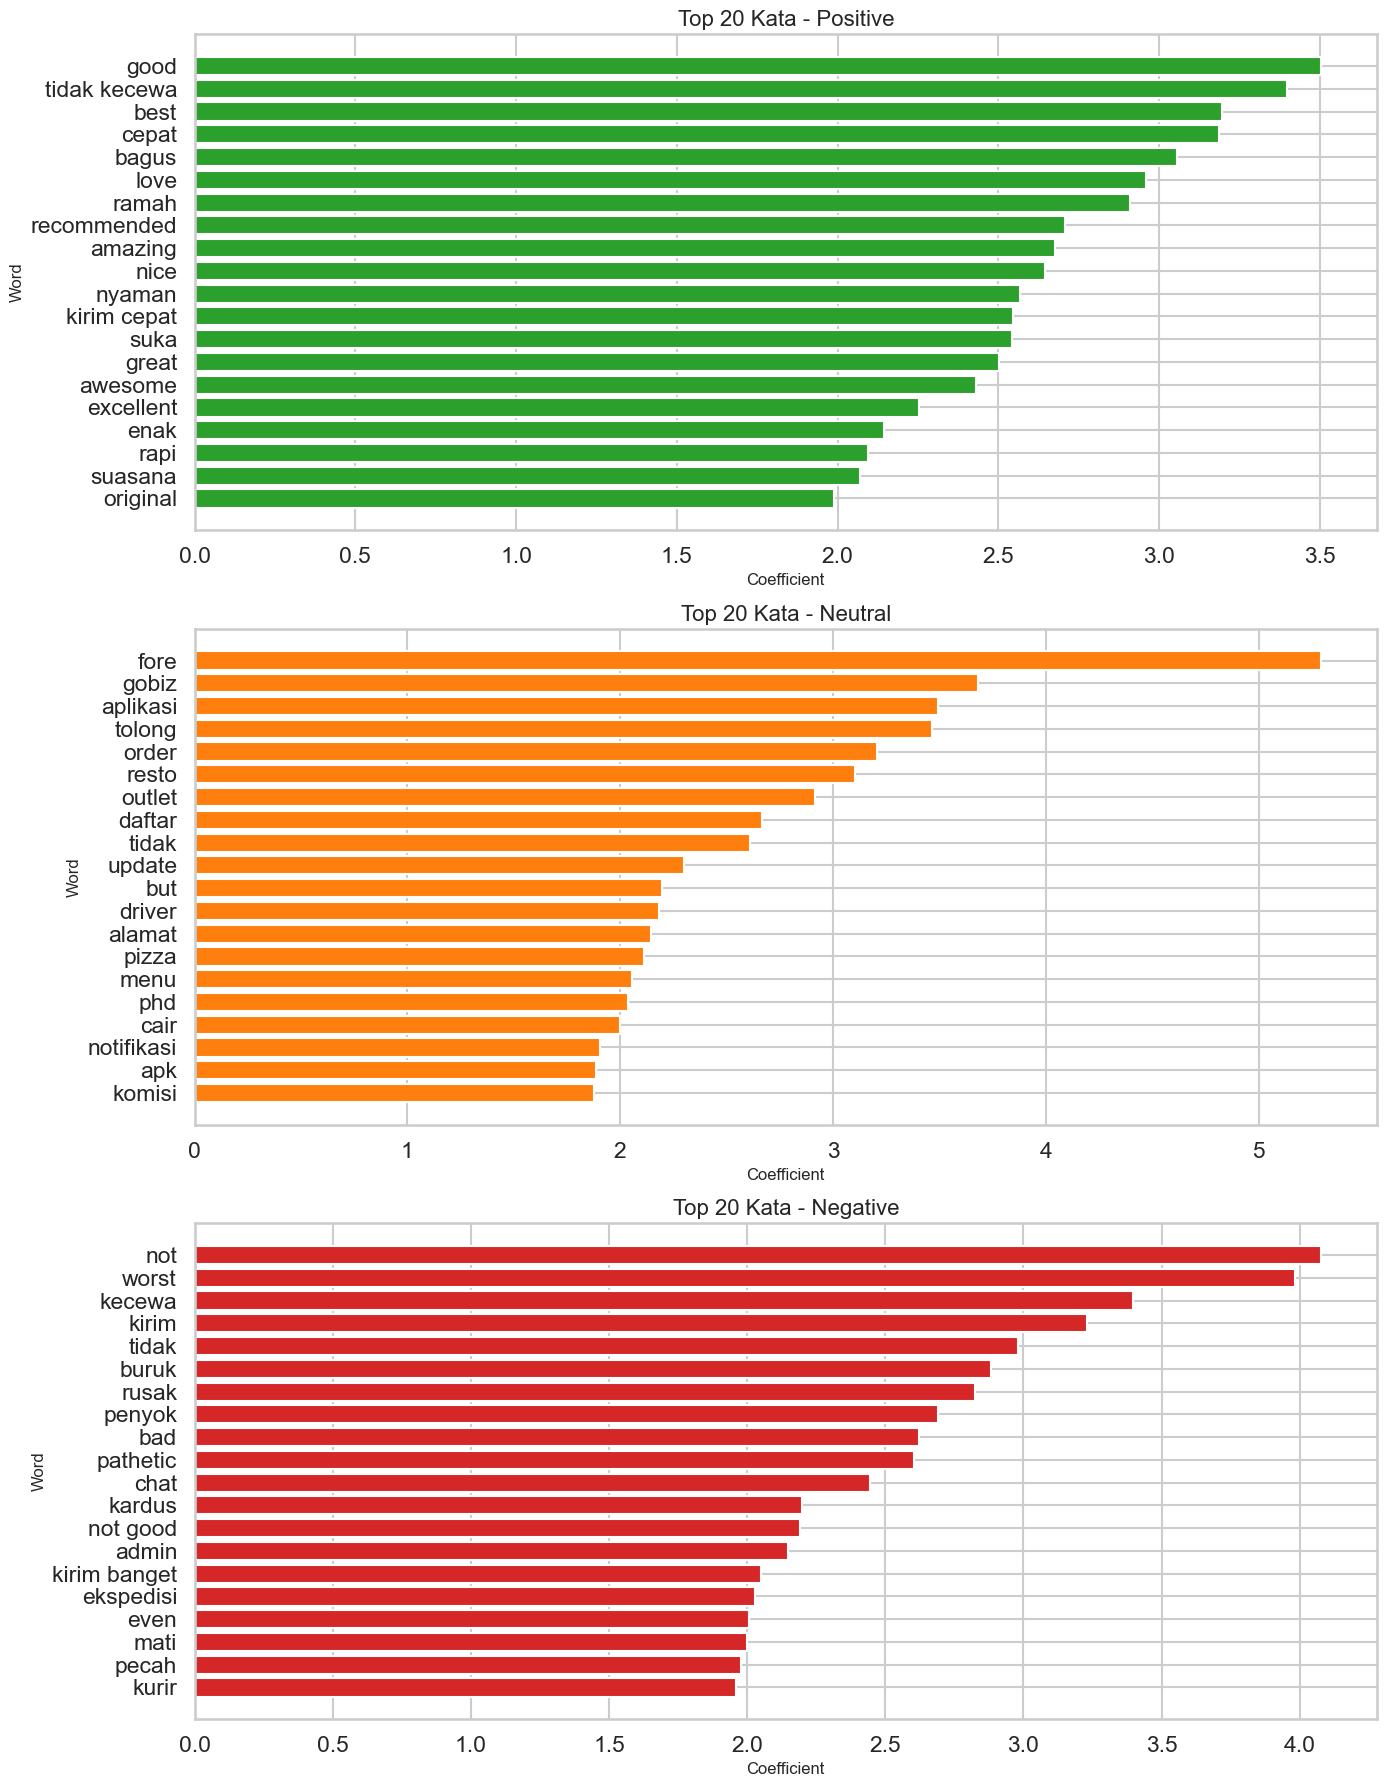

In [12]:
feature_names = np.array(final_vectorizer.get_feature_names_out())
coef = final_classifier.coef_

def resolve_class_index(class_name):
    encoded_value = label_mapping[class_name]
    return np.where(final_classifier.classes_ == encoded_value)[0][0]

explainable_tables = {}
for class_name in ['Positive', 'Neutral', 'Negative']:
    class_idx = resolve_class_index(class_name)
    class_coef = coef[class_idx]
    top_idx = np.argsort(class_coef)[-20:][::-1]
    table = pd.DataFrame({
        'feature': feature_names[top_idx],
        'coefficient': class_coef[top_idx],
    })
    explainable_tables[class_name] = table
    display(Markdown(f'### Top 20 Kata untuk Kelas {class_name}'))
    display(table)

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
colors = {'Positive': '#2ca02c', 'Neutral': '#ff7f0e', 'Negative': '#d62728'}
for ax, class_name in zip(axes, ['Positive', 'Neutral', 'Negative']):
    table = explainable_tables[class_name].sort_values('coefficient', ascending=True)
    ax.barh(table['feature'], table['coefficient'], color=colors[class_name])
    ax.set_title(f'Top 20 Kata - {class_name}')
    ax.set_xlabel('Coefficient')
    ax.set_ylabel('Word')
plt.tight_layout()
plt.show()

## SECTION 13 - Business Analysis

Analisis bisnis digunakan untuk melihat apakah model bekerja konsisten pada subset data tertentu.

Subgroup yang dianalisis:
- `Crisis_Flag`
- `Is_Sarcasm`
- `Business_Category`

Tujuannya adalah mengecek apakah ada segmentasi data yang secara sistematis lebih sulit diprediksi.

,Crisis_Flag,count,accuracy,precision_macro,recall_macro,f1_macro
0,No,4602,0.758366,0.753258,0.755717,0.753827
1,Yes,407,0.914005,0.333333,0.304668,0.318357


,Is_Sarcasm,count,accuracy,precision_macro,recall_macro,f1_macro
0,No,4946,0.770926,0.770176,0.770997,0.770206
1,Yes,63,0.777778,0.333333,0.259259,0.291667


,Business_Category,count,accuracy,precision_macro,recall_macro,f1_macro
1,F&B,3567,0.757499,0.742149,0.750871,0.745942
6,Kesehatan & Kecantikan,50,0.860000,0.760417,0.699234,0.722533
10,Perawatan Hewan,24,0.791667,0.685185,0.719373,0.696296
5,Kerajinan & Pesta,21,0.952381,0.666667,0.641026,0.653333
11,Perlengkapan Kantor,16,0.937500,0.666667,0.633333,0.649123
8,Otomotif,17,0.941176,0.666667,0.629630,0.647059
3,Hobi & Hiburan,73,0.753425,0.608276,0.603488,0.603888
0,Elektronik,92,0.695652,0.715764,0.599575,0.575158
7,Lainnya,1009,0.829534,0.568247,0.885761,0.571866
9,Perabotan,48,0.729167,0.565657,0.561538,0.556183


C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_15632\701132784.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crisis_metrics, x='Crisis_Flag', y='f1_macro', ax=axes[0], palette='coolwarm')
C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_15632\701132784.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sarcasm_metrics, x='Is_Sarcasm', y='f1_macro', ax=axes[1], palette='magma')


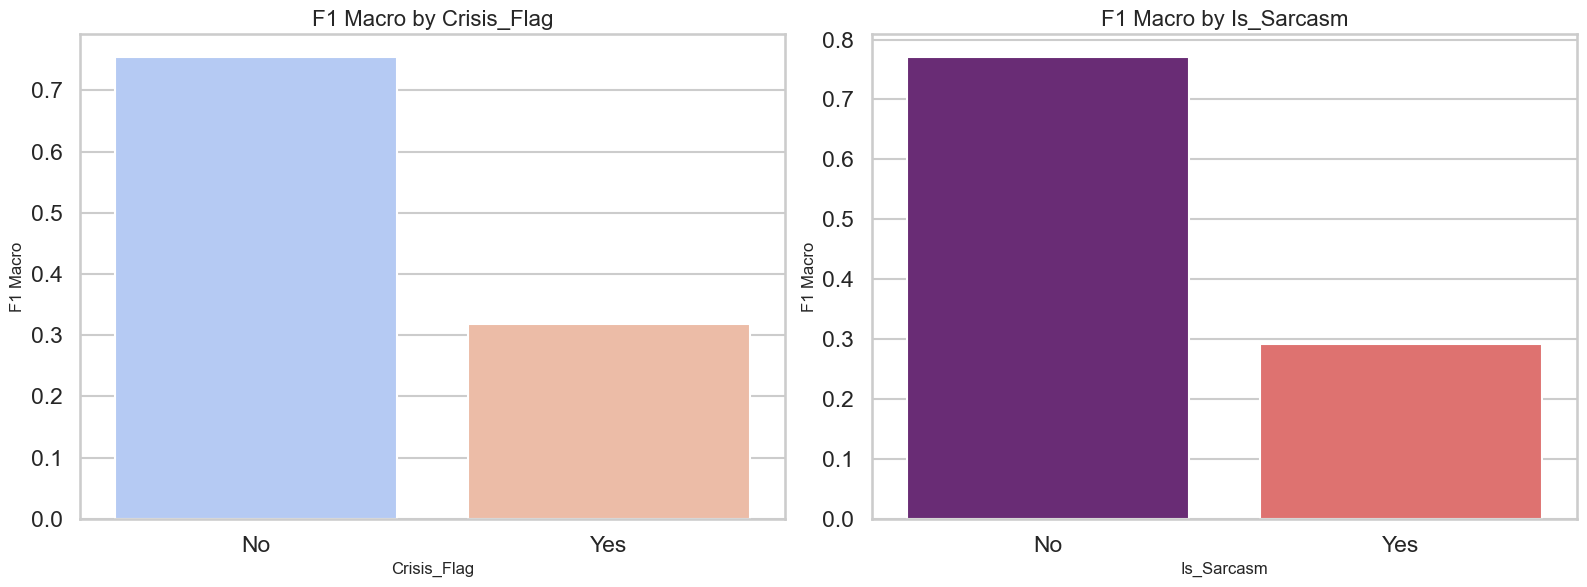

C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_15632\701132784.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_plot, y='Business_Category', x='f1_macro', ax=ax, palette='viridis')


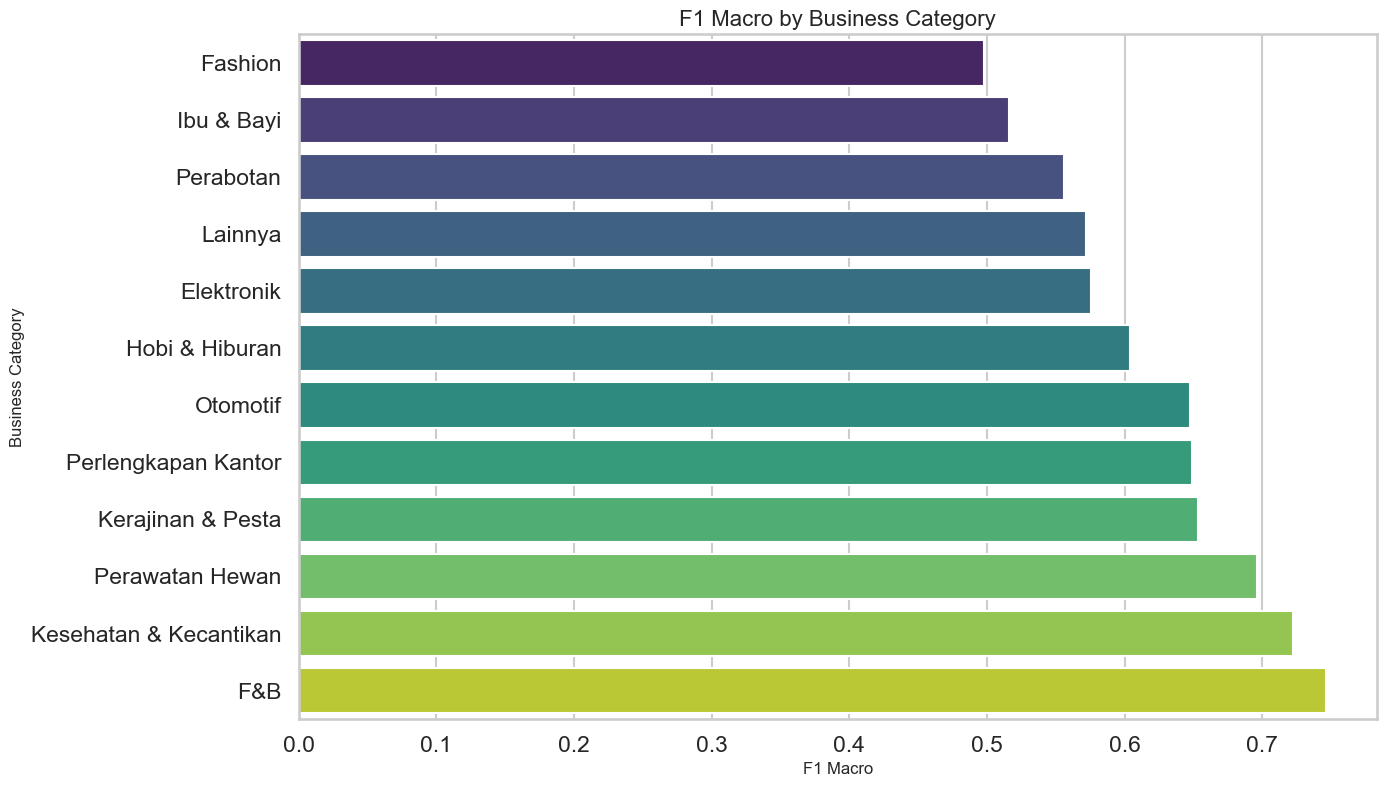

In [13]:
def subgroup_metrics(df_source, actual_array, pred_array, group_col, min_count=1):
    temp = df_source[[group_col]].copy()
    temp['Actual'] = actual_array
    temp['Predicted'] = pred_array
    rows = []
    for group_value, group_df in temp.groupby(group_col):
        if len(group_df) < min_count:
            continue
        rows.append({
            group_col: group_value,
            'count': len(group_df),
            'accuracy': accuracy_score(group_df['Actual'], group_df['Predicted']),
            'precision_macro': precision_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
            'recall_macro': recall_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
            'f1_macro': f1_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
        })
    return pd.DataFrame(rows).sort_values('f1_macro', ascending=False)

crisis_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Crisis_Flag')
sarcasm_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Is_Sarcasm')
category_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Business_Category', min_count=10)

display(crisis_metrics)
display(sarcasm_metrics)
display(category_metrics)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=crisis_metrics, x='Crisis_Flag', y='f1_macro', ax=axes[0], palette='coolwarm')
axes[0].set_title('F1 Macro by Crisis_Flag')
axes[0].set_xlabel('Crisis_Flag')
axes[0].set_ylabel('F1 Macro')

sns.barplot(data=sarcasm_metrics, x='Is_Sarcasm', y='f1_macro', ax=axes[1], palette='magma')
axes[1].set_title('F1 Macro by Is_Sarcasm')
axes[1].set_xlabel('Is_Sarcasm')
axes[1].set_ylabel('F1 Macro')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 8))
category_plot = category_metrics.sort_values('f1_macro', ascending=True)
sns.barplot(data=category_plot, y='Business_Category', x='f1_macro', ax=ax, palette='viridis')
ax.set_title('F1 Macro by Business Category')
ax.set_xlabel('F1 Macro')
ax.set_ylabel('Business Category')
plt.tight_layout()
plt.show()

## SECTION 14 - Model Saving

Agar model dapat digunakan kembali tanpa retraining, notebook menyimpan tiga artefak utama:
- TF-IDF Vectorizer
- Label Encoder
- Logistic Regression Model

Seluruh artefak disimpan menggunakan Joblib.

In [14]:
# SAVE & VERIFY MODEL ARTIFACTS

artifacts_dir = Path("artifacts/model1")
artifacts_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Save Components
joblib.dump(
    final_vectorizer,
    artifacts_dir / "tfidf_vectorizer.joblib"
)

joblib.dump(
    label_encoder,
    artifacts_dir / "label_encoder.joblib"
)

joblib.dump(
    final_classifier,
    artifacts_dir / "logistic_regression_model.joblib"
)

# Save Complete Pipeline
joblib.dump(
    final_model,
    artifacts_dir / "logistic_regression_pipeline.joblib"
)

print("=" * 60)
print("MODEL ARTIFACTS SAVED")
print("=" * 60)

for file in artifacts_dir.glob("*"):
    print(file.name)

# VERIFY SAVED PIPELINE

loaded_pipeline = joblib.load(
    artifacts_dir / "logistic_regression_pipeline.joblib"
)

sample_text = [
    "makanan enak pelayanan cepat dan memuaskan"
]

prediction = loaded_pipeline.predict(sample_text)

predicted_label = label_encoder.inverse_transform(
    prediction
)

print("\nSample Prediction:")
print(predicted_label[0])

print("\nSaved to:")
print(artifacts_dir.resolve())

MODEL ARTIFACTS SAVED
label_encoder.joblib
logistic_regression_model.joblib
logistic_regression_pipeline.joblib
tfidf_vectorizer.joblib

Sample Prediction:
Positive

Saved to:
C:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\artifacts\model1


## SECTION 15 - Export Result

Section ini mengekspor hasil eksperimen agar dapat dipakai langsung untuk pelaporan capstone, audit model, dan dokumentasi advisor meeting.

File yang disimpan:
- `metrics_logistic_regression.csv`
- `prediction_logistic_regression.csv`
- `classification_report_logistic_regression.csv`

In [15]:
results_dir = Path('results/model1')
results_dir.mkdir(
    parents=True,
    exist_ok=True
)

metrics_export = pd.DataFrame([
    {
        'split': 'validation',
        'accuracy': val_metrics['accuracy'],
        'precision_macro': val_metrics['precision_macro'],
        'recall_macro': val_metrics['recall_macro'],
        'f1_macro': val_metrics['f1_macro'],
    },
    {
        'split': 'test',
        'accuracy': test_metrics['accuracy'],
        'precision_macro': test_metrics['precision_macro'],
        'recall_macro': test_metrics['recall_macro'],
        'f1_macro': test_metrics['f1_macro'],
    },
])
metrics_export.to_csv(results_dir / 'metrics_logistic_regression.csv', index=False)

prediction_export = pd.concat([
    pd.DataFrame({
        'split': 'validation',
        'Review_Text_Processed': X_val.values,
        'Actual_Label': pd.Series(val_y).map(inverse_label_mapping).values,
        'Predicted_Label': pd.Series(val_pred).map(inverse_label_mapping).values,
        **{f'prob_{cls}': val_proba[:, idx] for idx, cls in enumerate(class_names)},
    }),
    pd.DataFrame({
        'split': 'test',
        'Review_Text_Processed': X_test.values,
        'Actual_Label': pd.Series(test_y).map(inverse_label_mapping).values,
        'Predicted_Label': pd.Series(test_pred).map(inverse_label_mapping).values,
        **{f'prob_{cls}': test_proba[:, idx] for idx, cls in enumerate(class_names)},
    }),
], ignore_index=True)
prediction_export.to_csv(results_dir / 'prediction_logistic_regression.csv', index=False)

def report_to_export_df(report_df, split_name):
    temp = report_df.copy()
    temp['split'] = split_name
    return temp[['split', 'label', 'precision', 'recall', 'f1-score', 'support']]

classification_report_export = pd.concat([
    report_to_export_df(val_report_df, 'validation'),
    report_to_export_df(test_report_df, 'test'),
], ignore_index=True)
classification_report_export.to_csv(results_dir / 'classification_report_logistic_regression.csv', index=False)

print('Exported files to:', results_dir.resolve())
display(metrics_export)
display(prediction_export.head())
display(classification_report_export.head())

Exported files to: C:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\results\model1


,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.775075,0.774661,0.775092,0.774682
1,test,0.771012,0.770407,0.771088,0.770374


,split,Review_Text_Processed,Actual_Label,Predicted_Label,prob_Negative,prob_Neutral,prob_Positive
0,validation,tolong driver kasi dekat dsri resto krena kalo driver banyak tidak ambil pesan udah ready alhasil resto rugi aju kompensasi harga bbrp persen doang total harga makan,Neutral,Neutral,0.107282,0.882728,0.009990
1,validation,harap fitur chat resto langgan seringkali langgan kasih note driver driver telat pesan selesai fitur telpon tidak bantu nomor modifikasi beli tidak angkat pikir telpon spam pasrah pas kasih rating bintang langgan miskomunikasi langgan paham menu ...,Neutral,Neutral,0.051352,0.943177,0.005471
2,validation,shantanu ali and team given me great experience for my 1st time experience in ab suggest my friends to visit and refer you all who read this approach them for your great experience,Positive,Positive,0.098322,0.044823,0.856855
3,validation,layan ramah oke banget waitress gyukaku riau kokom haris dan meta,Positive,Positive,0.041577,0.041975,0.916447
4,validation,we ordered butter chicken paneer makhani dal makhani and mango lassi the gravies had no distinctive they were overtly sweet and tasted nothing like the original dishes the dal makhani was tolerable but not good since it mango season expected the ...,Negative,Negative,0.436694,0.403997,0.159309


,split,label,precision,recall,f1-score,support
0,validation,Negative,0.770344,0.763441,0.766877,1674.000000
1,validation,Neutral,0.760991,0.735488,0.748022,1671.000000
2,validation,Positive,0.792648,0.826347,0.809147,1670.000000
3,validation,accuracy,0.775075,0.775075,0.775075,0.775075
4,validation,macro avg,0.774661,0.775092,0.774682,5015.000000


## SECTION 16 - Final Conclusion

Ringkasan otomatis berikut dihasilkan dari metrik validasi dan test. Bagian ini dapat langsung dipakai sebagai bahan narasi laporan capstone atau diskusi advisor meeting.

In [16]:
summary_df = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Validation_F1": [val_metrics["f1_macro"]],
    "Test_F1": [test_metrics["f1_macro"]],
    "TFIDF": [str(BEST_TFIDF_PARAMS)]
})

display(summary_df)

,Model,Validation_F1,Test_F1,TFIDF
0,Logistic Regression,0.774682,0.770374,"{'ngram_range': (1, 2), 'max_features': 20000, 'min_df': 2, 'max_df': 0.95}"


In [17]:
final_conclusion_md = f'''
### Final Conclusion

**Validation Performance**
- Accuracy: {val_metrics['accuracy']:.4f}
- Precision: {val_metrics['precision_macro']:.4f}
- Recall: {val_metrics['recall_macro']:.4f}
- F1 Score: {val_metrics['f1_macro']:.4f}

**Test Performance**
- Accuracy: {test_metrics['accuracy']:.4f}
- Precision: {test_metrics['precision_macro']:.4f}
- Recall: {test_metrics['recall_macro']:.4f}
- F1 Score: {test_metrics['f1_macro']:.4f}

**Kelebihan Model**
- Logistic Regression memberikan baseline yang stabil, cepat, dan mudah diinterpretasikan.
- TF-IDF memungkinkan model bekerja efektif pada teks sparse tanpa training yang berat.
- Koefisien model dapat digunakan untuk explainability sehingga cocok untuk laporan akademik.

**Kekurangan Model**
- Model linear kurang kuat untuk menangkap konteks yang sangat kompleks, sarcasm, dan negasi yang jauh.
- Performa sangat bergantung pada kualitas preprocessing dan representasi TF-IDF.
- Kata-kata yang ambigu atau sangat domain-spesifik masih dapat memicu salah klasifikasi.

'''

display(Markdown(final_conclusion_md))


### Final Conclusion

**Validation Performance**
- Accuracy: 0.7751
- Precision: 0.7747
- Recall: 0.7751
- F1 Score: 0.7747

**Test Performance**
- Accuracy: 0.7710
- Precision: 0.7704
- Recall: 0.7711
- F1 Score: 0.7704

**Kelebihan Model**
- Logistic Regression memberikan baseline yang stabil, cepat, dan mudah diinterpretasikan.
- TF-IDF memungkinkan model bekerja efektif pada teks sparse tanpa training yang berat.
- Koefisien model dapat digunakan untuk explainability sehingga cocok untuk laporan akademik.

**Kekurangan Model**
- Model linear kurang kuat untuk menangkap konteks yang sangat kompleks, sarcasm, dan negasi yang jauh.
- Performa sangat bergantung pada kualitas preprocessing dan representasi TF-IDF.
- Kata-kata yang ambigu atau sangat domain-spesifik masih dapat memicu salah klasifikasi.

